In [2]:
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
def fillna(df):
    df['분야'].fillna('None')
    df['직원 수'].fillna(df['직원 수'].median(), inplace = True)
    df['고객수(백만명)'].fillna(df['고객수(백만명)'].median(), inplace= True)
    df['기업가치(백억원)'].fillna('0000').astype(str)
    return df 
def change(df):
    df['기업가치(백억원)'] = df['기업가치(백억원)'].str.extract(r'(\d{1,4})')[0].fillna('0').astype(int)
    return df
def drop(df):
    df.drop('ID', axis = 1, inplace = True)
    return df
def format_features(df):
    features = ['국가', '분야', '투자단계', '인수여부', '상장여부', '기업가치(백억원)']
    for feature in features:
        le = LabelEncoder()
        le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df


In [3]:
import pandas as pd
train= pd.read_csv('company_train.csv')
test = pd.read_csv('company_test.csv')

In [4]:
def transform_features(df):
    df = fillna(df)
    df = change(df)
    df = drop(df)
    df = format_features(df)
    return df



In [5]:
train =transform_features(train)
test = transform_features(test)

C:\Users\sjune\AppData\Local\Temp\ipykernel_24112\306107799.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['직원 수'].fillna(df['직원 수'].median(), inplace = True)
C:\Users\sjune\AppData\Local\Temp\ipykernel_24112\306107799.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [6]:
#Scaling 
import pandas as pd 
from sklearn.preprocessing import StandardScaler

def scaling(df):
    df['운영연수'] = 2025 - df['설립연도']
    scale_cols = [
        '운영연수',
        '직원 수',
        '고객수(백만명)',
        '총 투자금(억원)', 
        '연매출(억원)', 
        'SNS 팔로워 수(백만명)', 
        '기업가치(백억원)'
    ]
    scaler = StandardScaler()
    df[scale_cols] = scaler.fit_transform(df[scale_cols])
    df.drop('설립연도', axis = 1, inplace = True)
    return df
    
        
    

In [7]:
train = scaling(train)
test = scaling(test)

In [8]:
train.head()

,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률,운영연수
0,4,6,2,1.167832,0,0,0.302072,0.026827,-0.446336,1.507250,-1.205150,0.3,0.458773
1,5,8,1,1.196770,1,0,1.360376,0.401317,-1.632103,-1.115718,-0.089724,0.8,-1.677287
2,6,2,2,0.466278,1,1,0.213880,1.669477,1.504034,1.005280,0.467990,0.5,-0.914408
3,5,10,1,0.546033,1,1,-0.006600,-1.409428,1.082604,0.277071,-1.205150,0.7,-0.609257
4,1,5,1,-0.354554,0,1,1.977720,-1.322189,0.887752,-1.115718,-0.647437,0.1,-1.219560


In [9]:
y = train['성공확률']

In [10]:
from sklearn.model_selection import train_test_split
X = train.drop('성공확률', axis = 1)
(X_train, X_val, y_train, y_val) = train_test_split(X, y, test_size = 0.2, random_state = 156)

In [11]:
X_test = test

In [12]:
from sklearn.preprocessing import scale
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
%matplotlib inline 


In [13]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 156)
kmeans.fit(X_train)
X_train['cluster'] = kmeans.labels_

In [14]:
print("클러스터 중심 좌표:\n", kmeans.cluster_centers_)
print("각 데이터의 클러스터 할당:\n", kmeans.labels_)
print("총 거리 제곱합 (inertia):", kmeans.inertia_)


클러스터 중심 좌표:
 [[ 7.18864293e+00  7.81231954e+00  2.00481232e+00  1.49941512e-02
   5.23580366e-01  4.96631376e-01  1.07155586e-02 -4.05020174e-02
  -3.72142170e-02 -1.37380531e-02 -6.34213647e-02 -1.42262609e-02]
 [ 4.45866862e+00  1.95318215e+00  1.94220922e+00  8.38287367e-02
   5.01828822e-01  4.74762253e-01 -2.32451644e-02  5.96327697e-02
   1.65714649e-02 -3.85679227e-03  1.48130796e-01 -1.40218331e-02]
 [ 1.84643510e+00  7.75319927e+00  1.92961609e+00 -8.67863724e-02
   5.10054845e-01  4.80804388e-01  2.06574065e-03 -3.36093787e-02
   1.88812457e-02  5.71383503e-02 -1.41212606e-01  5.26483804e-02]]
각 데이터의 클러스터 할당:
 [2 0 2 ... 0 0 2]
총 거리 제곱합 (inertia): 58881.2591195452


In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca_transformed = pca.fit_transform(X_train)

In [16]:
X_train['pca_x'] = pca_transformed[:,0]
X_train['pca_y'] = pca_transformed[:,1]

In [17]:
X_train.head()

,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),운영연수,cluster,pca_x,pca_y
4164,1,10,0,-1.183856,1,0,-0.006600,-1.300911,-1.620206,-0.606679,-0.647437,0.153622,2,4.504523,-3.646191
1233,7,6,0,0.809998,1,1,-0.359368,0.435894,0.221501,0.899230,-1.205150,0.916500,0,0.570427,2.626600
3774,4,10,3,-0.348908,0,1,-0.006600,1.034333,1.444018,0.178091,-1.205150,-0.914408,2,4.572876,-0.676457
4108,2,6,2,1.468499,0,0,-0.006600,1.422654,-0.235621,1.203240,-1.205150,0.153622,2,0.528824,-2.608141
768,5,4,3,-1.672967,1,1,-1.638152,1.541278,0.154876,1.005280,-0.089724,0.611349,1,-1.484647,0.533060


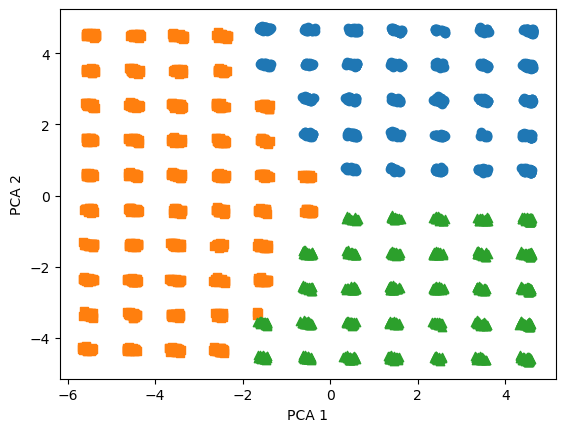

In [18]:
marker0_ind = X_train[X_train['cluster']==0].index
marker1_ind = X_train[X_train['cluster']==1].index
marker2_ind = X_train[X_train['cluster']==2].index


plt.scatter(x = X_train.loc[marker0_ind, 'pca_x'],y = X_train.loc[marker0_ind, 'pca_y'],marker = 'o')
plt.scatter(x = X_train.loc[marker1_ind, 'pca_x'],y = X_train.loc[marker1_ind, 'pca_y'],marker = 's')
plt.scatter(x = X_train.loc[marker2_ind, 'pca_x'],y = X_train.loc[marker2_ind, 'pca_y'],marker = '^')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [19]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components = 3)
pca_transformed1 = pca1.fit_transform(X_train)

In [20]:
X_train['pca_x1'] = pca_transformed1[:,0]
X_train['pca_y1'] = pca_transformed1[:,1]
X_train['pca_z1'] = pca_transformed1[:,2]

In [21]:
X_train.head()

,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),운영연수,cluster,pca_x,pca_y,pca_x1,pca_y1,pca_z1
4164,1,10,0,-1.183856,1,0,-0.006600,-1.300911,-1.620206,-0.606679,-0.647437,0.153622,2,4.504523,-3.646191,6.370358,-5.156492,-1.899582
1233,7,6,0,0.809998,1,1,-0.359368,0.435894,0.221501,0.899230,-1.205150,0.916500,0,0.570427,2.626600,0.806706,3.714574,-2.016381
3774,4,10,3,-0.348908,0,1,-0.006600,1.034333,1.444018,0.178091,-1.205150,-0.914408,2,4.572876,-0.676457,6.467023,-0.956655,1.030379
4108,2,6,2,1.468499,0,0,-0.006600,1.422654,-0.235621,1.203240,-1.205150,0.153622,2,0.528824,-2.608141,0.747870,-3.688468,0.070492
768,5,4,3,-1.672967,1,1,-1.638152,1.541278,0.154876,1.005280,-0.089724,0.611349,1,-1.484647,0.533060,-2.099608,0.753861,1.066339


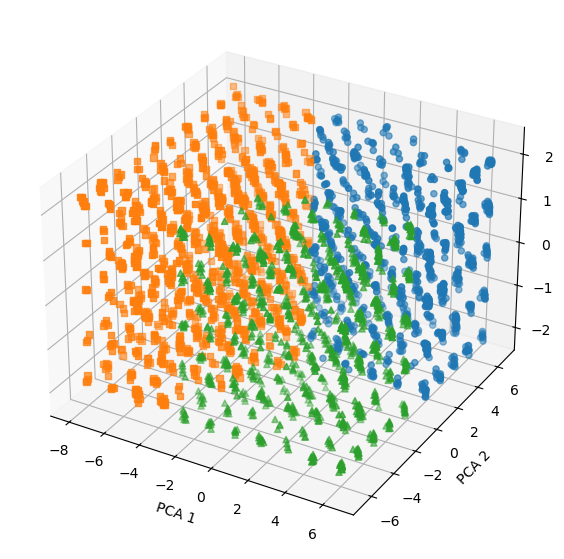

In [22]:
marker0_ind = X_train[X_train['cluster']==0].index
marker1_ind = X_train[X_train['cluster']==1].index
marker2_ind = X_train[X_train['cluster']==2].index
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_train.loc[marker0_ind, 'pca_x1'],X_train.loc[marker0_ind, 'pca_y1'],X_train.loc[marker0_ind, 'pca_z1'],marker = 'o')
scatter = ax.scatter(X_train.loc[marker1_ind, 'pca_x1'],X_train.loc[marker1_ind, 'pca_y1'],X_train.loc[marker1_ind, 'pca_z1'],marker = 's')
scatter = ax.scatter(X_train.loc[marker2_ind, 'pca_x1'],X_train.loc[marker2_ind, 'pca_y1'],X_train.loc[marker2_ind, 'pca_z1'],marker = '^')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')

plt.show()

In [23]:
def visualize_silhouette(X, cluster_range):
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score
    import matplotlib.cm as cm
    import matplotlib.pyplot as plt
    import numpy as np

    for n_clusters in cluster_range:
        fig, ax1 = plt.subplots(1, 1)
        fig.set_size_inches(8, 6)

        ax1.set_xlim([-0.1, 1])
        ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels = kmeans.fit_predict(X)

        silhouette_avg = silhouette_score(X, cluster_labels)
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                              0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)

            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
        ax1.set_title(f"Silhouette Plot for k = {n_clusters}(score = {silhouette_avg:.3f})")
        ax1.set_xlabel("Silhouette Coefficient Values")
        ax1.set_ylabel("Cluster Label")
        ax1.set_yticks([])
        plt.show()

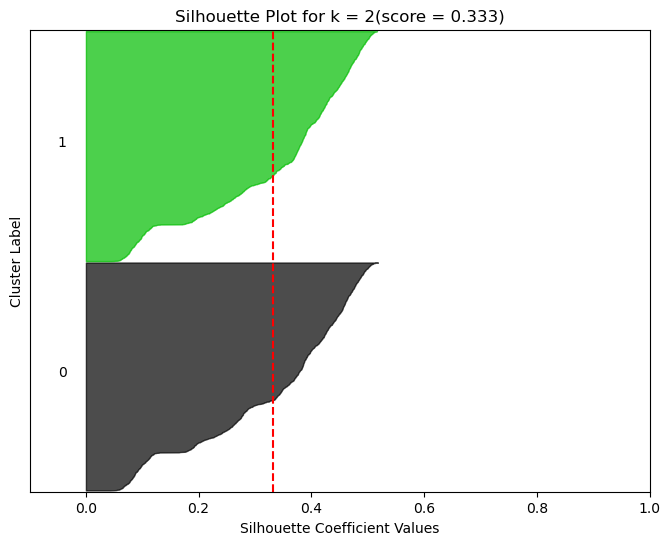

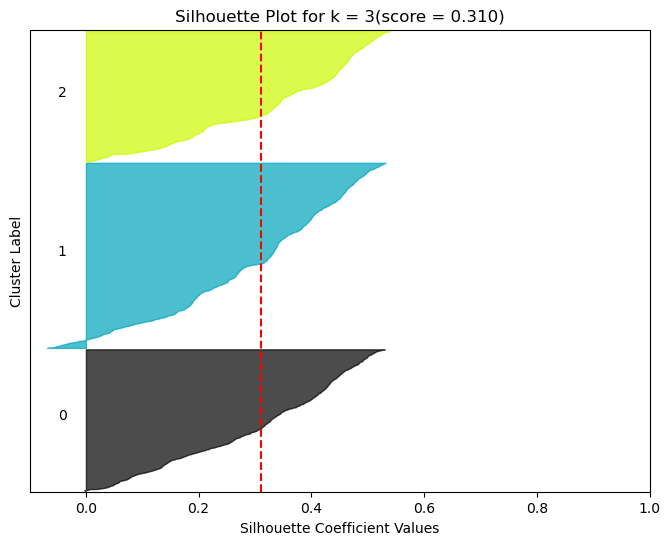

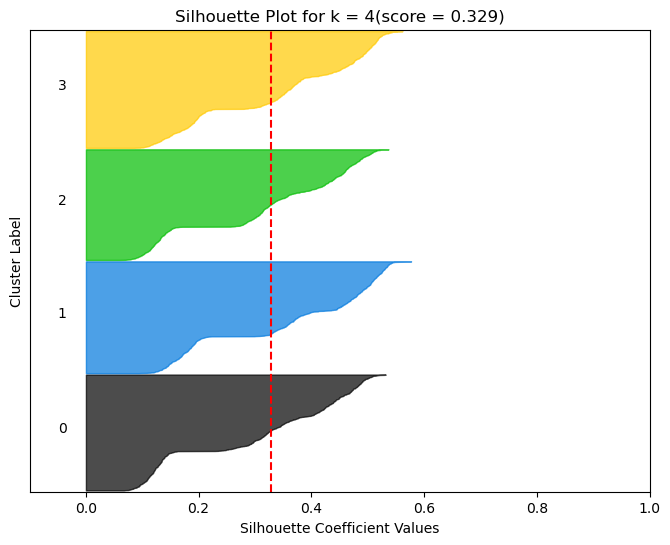

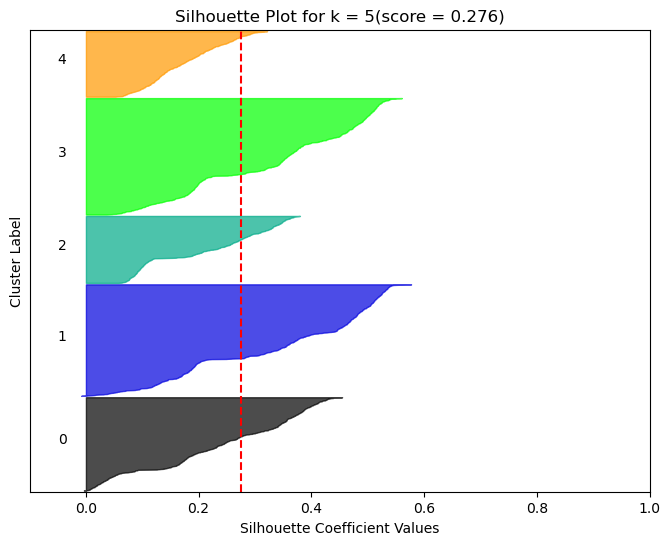

In [24]:
visualize_silhouette(X_train,[2, 3, 4, 5])

In [25]:
from sklearn.neighbors import KNeighborsRegressor
y = train['성공확률']
from sklearn.model_selection import train_test_split
X = train.drop('성공확률', axis = 1)
(X_train, X_val, y_train, y_val) = train_test_split(X, y, test_size = 0.2, random_state = 156)
X_test = test

knn = KNeighborsRegressor(n_neighbors=1350)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_val)

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.1941
MSE: 0.0532
RMSE: 0.2306
R² Score: 0.0014


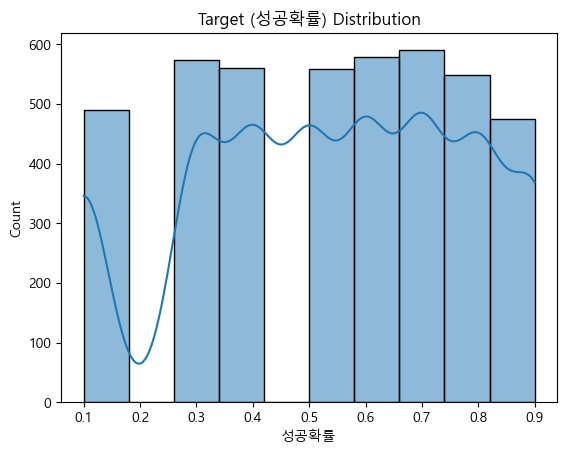

In [27]:
import seaborn as sns

import matplotlib.font_manager as fm

# 폰트 경로 찾기 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 또는 'NanumGothic', 'AppleGothic' (Mac)
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 부호 깨짐 방지
sns.histplot(train['성공확률'], bins=10, kde=True)
plt.title("Target (성공확률) Distribution")
plt.show()

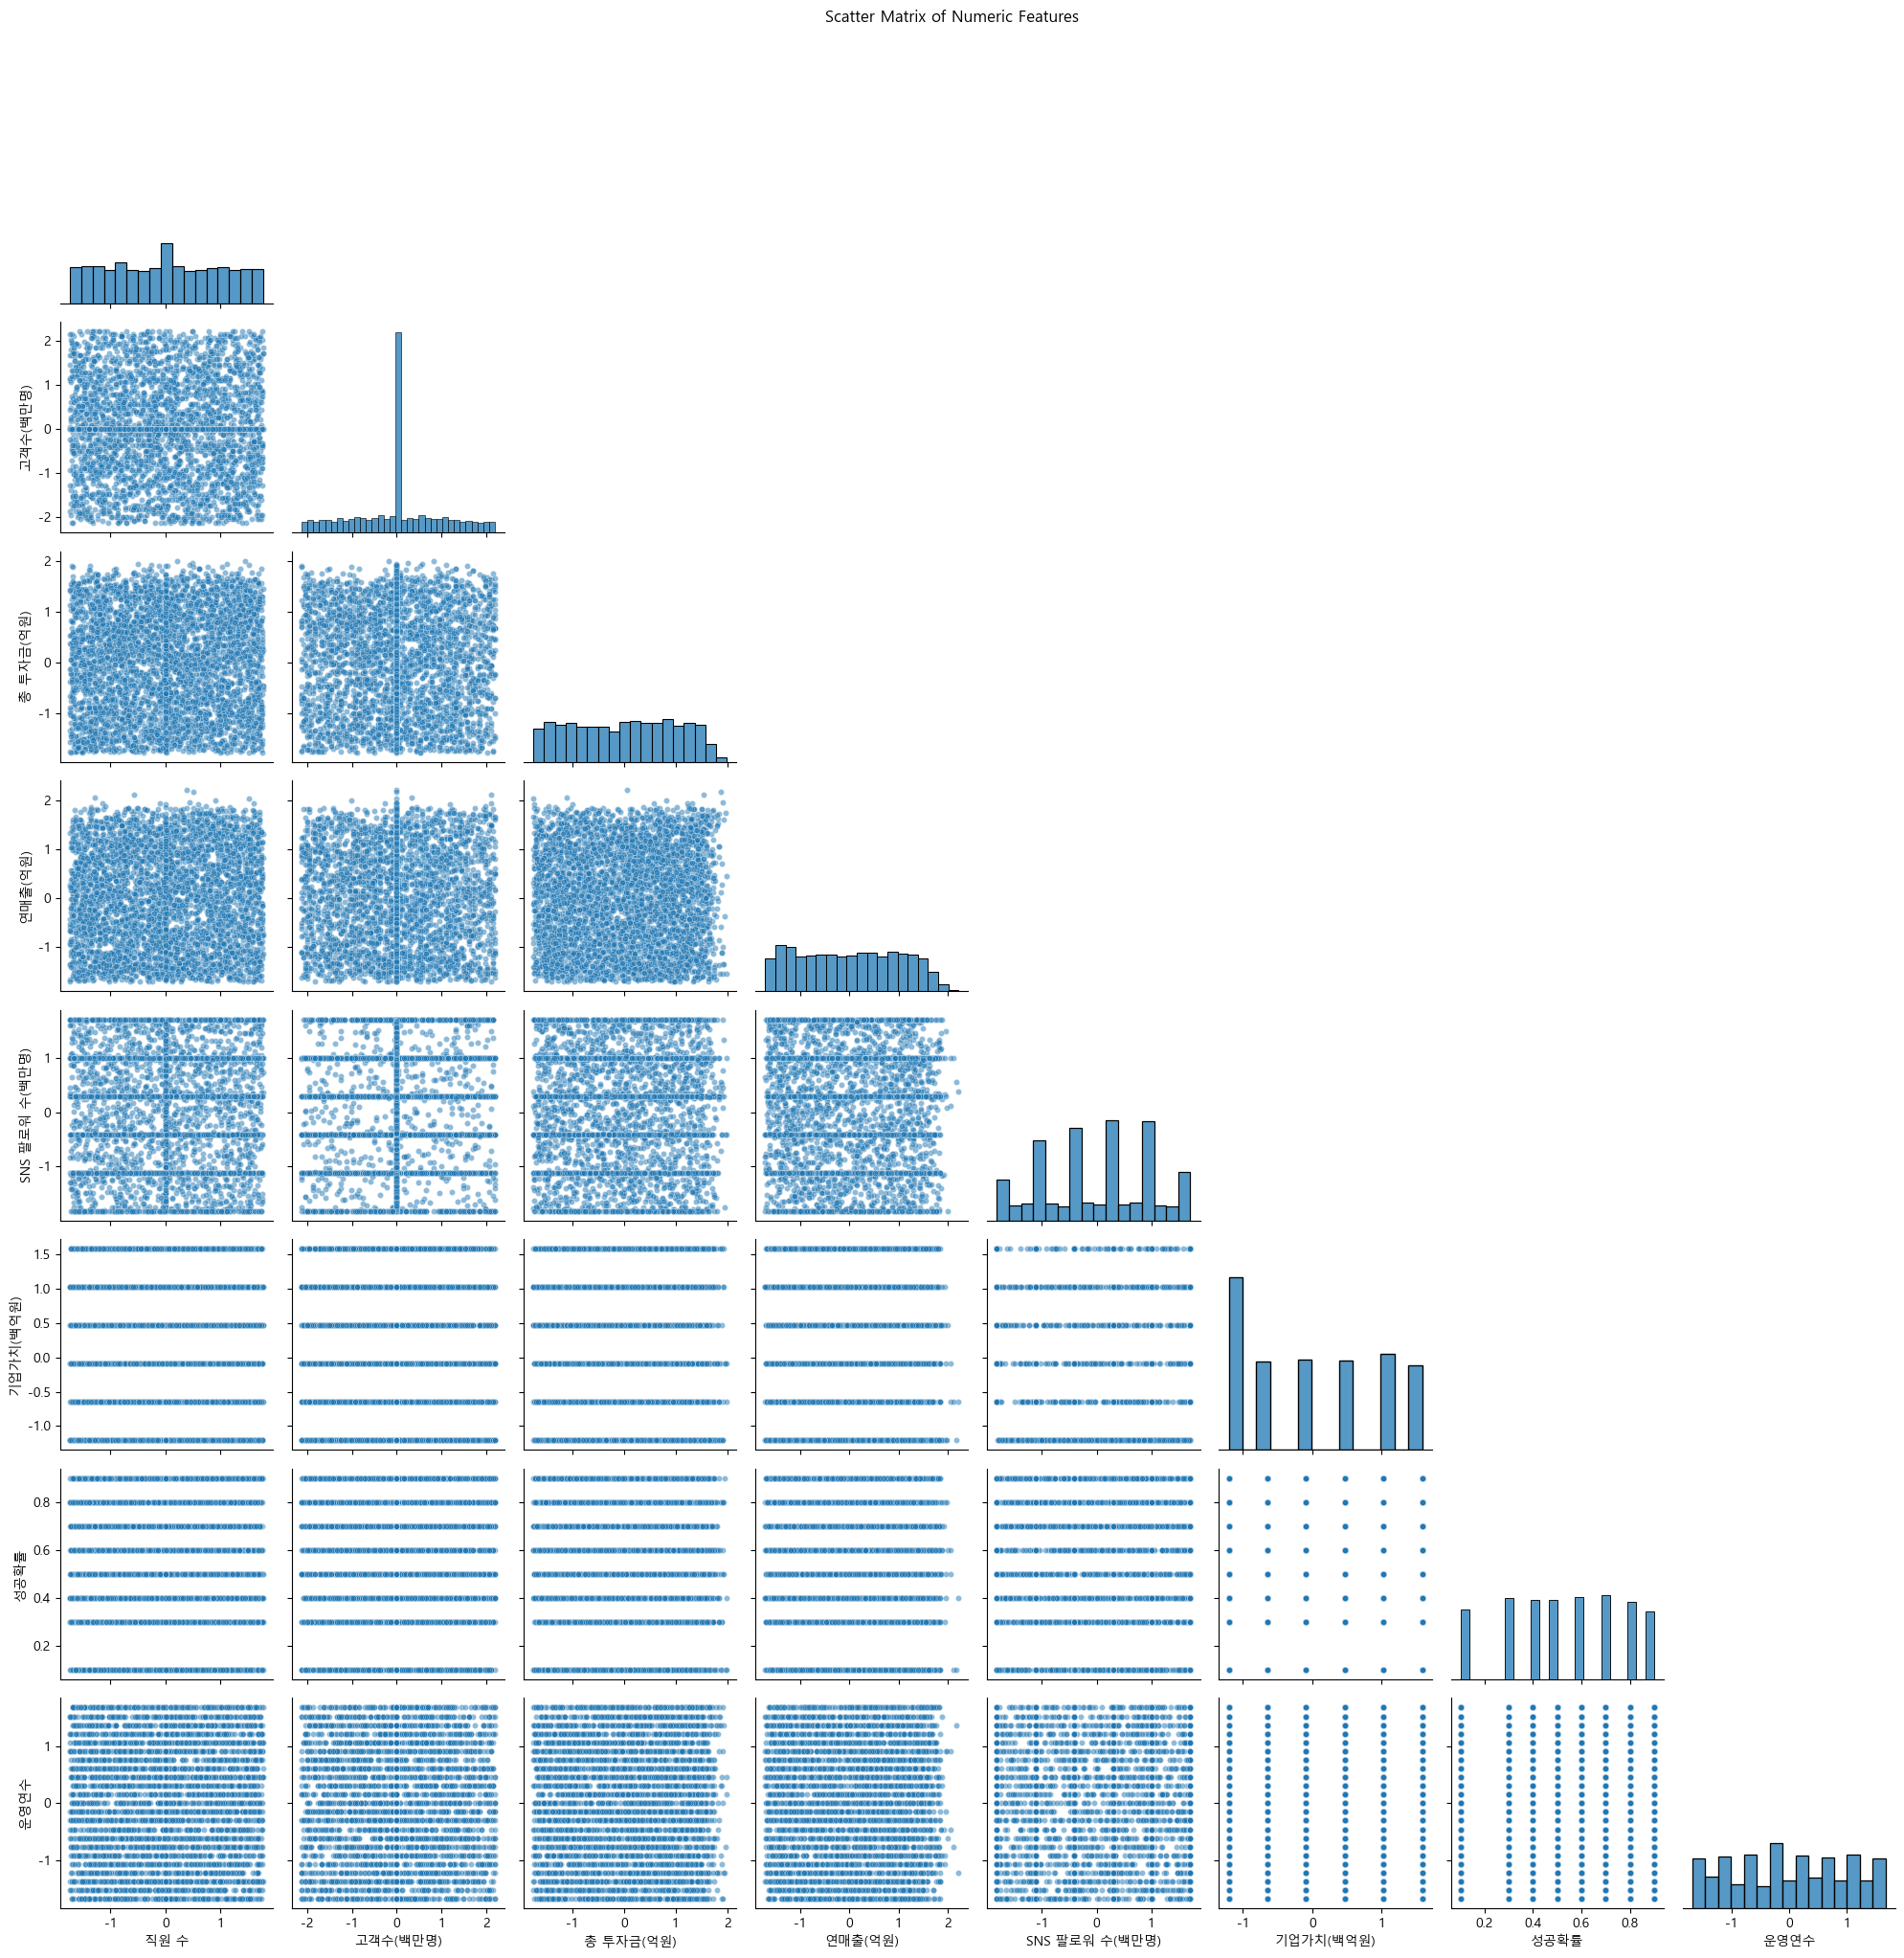

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 feature만 선택
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns

# pairplot: scatter + histogram 자동 표시
sns.pairplot(train[numeric_cols], corner=True, plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle("Scatter Matrix of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

In [34]:
#경향성이 적다... 따라서 성능이 낮았음... 분류 문제로 바꿔서 가야함 

y = train['성공확률']
from sklearn.model_selection import train_test_split
X = train.drop('성공확률', axis = 1)
(X_train, X_val, y_train, y_val) = train_test_split(X, y, test_size = 0.2, random_state = 156)
X_test = test

kmeans = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, random_state = 156)
kmeans.fit(X_train)
kmeans1 = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, random_state = 156)
kmeans1.fit(X_val)
kmeans2 = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, random_state = 156)
kmeans2.fit(X_test)
X_train['cluster'] = kmeans.labels_
X_val['cluster'] = kmeans1.labels_
X_test['cluster'] = kmeans2.labels_

C:\Users\sjune\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\sjune\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


In [38]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=1350)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_val)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.1941
MSE: 0.0532
RMSE: 0.2306
R² Score: 0.0012


In [39]:
y_train.head(100)

4164    0.1
1233    0.3
3774    0.7
4108    0.9
768     0.4
       ... 
484     0.7
530     0.8
2465    0.9
156     0.3
3051    0.4
Name: 성공확률, Length: 100, dtype: float64

In [41]:
sample_submission = pd.read_csv('sample_submission.csv')
final_predictions = knn.predict(X_test)
sample_submission['성공확률'] = final_predictions
sample_submission.to_csv('./knn_cluster_submission.csv', index = False, encoding = 'utf-8-sig')